<a href="https://colab.research.google.com/github/pachterlab/cellsweep/blob/main/notebooks/parameter_sweep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Parameter sweep: repulsion strength, per-gene cap, and the β prior

This notebook measures how sensitive CellSweep is to its regularization settings:

* **ρ** (`repulsion_strength`): how strongly cell-type profiles are pushed away from the ambient
  profile. Repulsion stays on through both training stages.
* **cap** (`max_frac_gene_repulsion`): the largest fraction of a gene's expected count that one
  repulsion step may remove. ρ and the cap interact: together they set how hard repulsion pushes,
  especially on genes that are abundant in the ambient profile.
* **κ** (`beta_prior_strength`): the weight of the Beta prior on the global contamination fraction β,
  as a fraction of the total counts (prior mode `beta_prior_mode = 0.01`).

The sweeps are centered on the model's defaults (ρ = 1e-3, κ = 1e-2, cap = 0.25; `init_beta = 0.01`):

1. **ρ × cap grid** (ρ ∈ {1e-5, 1e-4, 3e-4, 1e-3, 3e-3}, cap ∈ {0.1, 0.2, 0.25, 0.3, 0.4}) at the
   default stopping rule. ρ = 3e-3 lies above the default so that the default is not at the edge of the grid.
2. **κ sweep** at the default ρ and cap, default stopping.
3. **Convergence check**: every cap at the default ρ, run both with the default stopping rule and to
   convergence (3,000 iterations, tight tolerances). A setting is only useful if both runs agree.
   Convergence runs take most of the compute, so they are limited to this column.
4. **Initial ambient fraction** (`init_alpha` ∈ {0.1, 0.3, 0.5, 0.7, 0.9}) on `hgmm_12k` at the default ρ, κ
   and cap, default stopping. In a species mixture, the mass each cell-type profile puts on the other species'
   genes shows directly how much ambient RNA the profile has absorbed.

Results are scored against the ground truth each dataset offers:

| dataset | ground truth | noise removed | signal kept |
|---|---|---|---|
| `hgmm_12k` | species of each read (human–mouse mixture) | cross-species counts | same-species counts |
| `pbmc8k` | canonical immune markers | off-target marker counts | on-target marker counts; DC contamination as an over-correction flag |
| `kidney_nuclei_10k` | proximal tubule (PT) markers | PT markers in non-PT cells | PT markers in PT cells |
| `janssen_nuc2/3` | genotype (Janssen et al. 2023, *Genome Biol.* 24:140) | Kendall τ / RMSLE vs per-nucleus background; PT markers in non-PT nuclei | PT markers in PT nuclei |

The notebook is self-contained: any input it can't find is downloaded and prepared, and anything
already on disk at the locations the other notebooks use is reused. The Janssen metadata is stored
in Seurat `.RDS` files and needs `Rscript` on `PATH` (base R only). Remove the two Janssen entries
from `datasets` if R isn't available.

In [1]:
# try:
#     from cellsweep import denoise
# except ImportError:
#     print("cellsweep not found, installing...")
#     !pip install -U -q cellsweep[analysis]

In [2]:
import contextlib
import io
import os
import re
import subprocess
import time
import urllib.request
import zipfile

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from scipy.stats import kendalltau

import cellsweep.utils as cs_utils
from cellsweep import denoise

cellsweep_dir = os.path.dirname(os.path.abspath(""))

In [3]:
datasets = ["hgmm_12k", "pbmc8k", "kidney_nuclei_10k", "janssen_nuc2", "janssen_nuc3"]

default = dict(rho=1e-3, kappa=1e-2, cap=0.25)  # the model's defaults: the reference setting in every plot

# 1. rho x cap grid, default stopping
rho_grid = [1e-5, 1e-4, 3e-4, 1e-3, 3e-3]
cap_grid = [0.1, 0.2, 0.25, 0.3, 0.4]
# 2. beta prior strength at the default rho and cap, default stopping
kappa_grid = [0, 1e-3, 1e-2, 3e-2]
# 3. convergence check: every cap at the default rho, both stopping modes
long_cap = cap_grid

# Janssen inputs: split the authors' PT label by their Seurat clusters at this resolution (None keeps the
# authors' coarse labels); PT clusters with fewer than janssen_min_cluster nuclei are pooled into PT_other
janssen_label_resolution = 0.5
janssen_min_cluster = 50

modes = {
    "default": {},                                          # the model's own stopping rule
    "long": dict(tol_p=1e-8, tol_f=1e-8, max_iter=3000),    # run to convergence
}

threads = 16
overwrite = False   # rebuild inputs and rerun settings that already exist
quick = False       # True: only the default setting at default stopping (a fast end-to-end check)

data_root = os.path.join(cellsweep_dir, "notebooks", "data")
sweep_data_dir = os.path.join(data_root, "parameter_sweep")
out_dir = os.path.join(cellsweep_dir, "notebooks", "output", "parameter_sweep")
log_dir = os.path.join(out_dir, "logs")
results_csv = os.path.join(out_dir, "results.csv")
for d in (sweep_data_dir, out_dir, log_dir):
    os.makedirs(d, exist_ok=True)

## Prepare inputs

Each dataset is prepared once and cached. Every step first checks the location the other notebooks
use (`benchmarking.ipynb` for the 10x datasets, `janssen_snrna.ipynb` for Janssen) and reuses
anything it finds.

**10x datasets** are prepared the way `benchmarking.ipynb` prepares them, using each dataset's config
in `notebooks/config/`:
1. Call barcodes below the knee-plot cutoff at `expected_cells` non-cellular.
2. Label cell types. hgmm_12k uses species plus human–mouse doublet calls; the others use CellTypist.

In [4]:
def download(url, path):
    if os.path.exists(path):
        return "reused"
    os.makedirs(os.path.dirname(path), exist_ok=True)
    print(f"  downloading {url}")
    urllib.request.urlretrieve(url, path + ".part")
    os.replace(path + ".part", path)
    return "downloaded"


def prepare_10x(ds):
    """Raw 10x matrix with is_empty and celltype (and is_doublet for hgmm), as in benchmarking.ipynb."""
    out = os.path.join(sweep_data_dir, f"{ds}_input.h5ad")
    if os.path.exists(out) and not overwrite:
        print(f"{ds}: reused {out}")
        return out
    cfg = cs_utils.load_dataset_yaml(os.path.join(cellsweep_dir, "notebooks", "config", f"{ds}.yaml"))
    raw_path = os.path.join(data_root, ds, os.path.basename(cfg["adata_raw_url"]))
    print(f"{ds}: raw matrix {download(cfg['adata_raw_url'], raw_path)} ({raw_path})")

    adata = cs_utils.load_adata(raw_path)
    adata.var_names_make_unique()
    expected_cells = cfg["expected_cells"]
    umi_cutoff = cs_utils.knee_plot(adata, expected_cells=expected_cells, show=False)
    adata = cs_utils.infer_empty_droplets(adata, method="threshold", umi_cutoff=umi_cutoff)

    if ds == "hgmm_12k":
        is_h = (adata.var["genome"] == "hg19").values
        h = np.asarray(adata.X[:, is_h].sum(axis=1)).ravel()
        m = np.asarray(adata.X[:, ~is_h].sum(axis=1)).ravel()
        adata.obs["celltype"] = np.where(h >= m, "hg19", "mm10")
        sc.pp.filter_cells(adata, min_counts=1)
        adata = cs_utils.detect_doublets_human_mouse(adata, fraction_doublet=cfg["fraction_doublet"], plot_empty=False,
                                                     umi_cutoff=umi_cutoff, expected_cells=expected_cells, show=False)
    else:
        adata = cs_utils.determine_cell_types(adata, model_pkl=cfg["model_pkl"], filter_empty=True,
                                              expected_cells=expected_cells, celltypist_convert=cfg["celltypist_convert"],
                                              celltypist_map_file=cfg["celltypist_map_file"])

    adata.uns["umi_cutoff"] = float(umi_cutoff)
    adata.write_h5ad(out)
    print(f"{ds}: built {out}")
    return out

**Janssen et al. (2023)** pooled kidneys from three mouse strains before droplet capture. Reads that
carry a foreign allele are background, which gives a per-nucleus background estimate (`bRNA`) for
the CAST nuclei. The inputs are built the same way `janssen_snrna.ipynb` builds them:
* the authors' called nuclei and cell types,
* every other barcode with 0 < UMI < 100 treated as non-cellular,
* the rest dropped.

The authors' proximal-tubule (PT) label covers most nuclei and several distinct PT populations. With
that coarse label, CellSweep's burn-in moves hundreds of poorly fit PT nuclei into a nearly empty
cell type (and warns about it), and those nuclei get poorly determined contamination estimates. As
label-based methods are best given labels at the resolution of the data, the sweep splits PT by the
authors' own Seurat clusters (`janssen_label_resolution`; `None` restores the coarse labels). Scores
are always computed with the authors' labels, so "PT" still means every PT nucleus.

In [5]:
JANSSEN_DIR = os.path.join(data_root, "janssen2023")
JANSSEN_ZENODO = "https://zenodo.org/records/7328632/files"
JANSSEN_EMPTY_UMI = 100
PT_MARKERS = ["Slc34a1", "Miox", "Pck1", "Slc4a4", "Ttc36", "Lrp2", "Fbp1", "Cyp2e1", "Fut9", "Khk"]
CONSTITUTIVE = ["Malat1", "Fth1", "Ftl1", "Tpt1", "Psap", "App"]

R_EXPORT = r"""
suppressWarnings({
  for (d in commandArgs(TRUE)) {
    md <- as.data.frame(attr(readRDS(file.path(d, "seurat.RDS")), "meta.data"))
    md$cell <- rownames(md)
    write.csv(md, file.path(d, "seurat_metadata.csv"), row.names = FALSE)
  }
})
"""


def prepare_janssen(rep):
    rep_dir = os.path.join(JANSSEN_DIR, rep)
    out = os.path.join(rep_dir, f"adata_raw_empty{JANSSEN_EMPTY_UMI}.h5ad")
    if os.path.exists(out) and not overwrite:
        print(f"janssen_{rep}: reused {out}")
        return out

    if not os.path.isdir(rep_dir):
        zip_path = os.path.join(JANSSEN_DIR, f"{rep}.zip")
        download(f"{JANSSEN_ZENODO}/{rep}.zip?download=1", zip_path)
        with zipfile.ZipFile(zip_path) as zf:
            zf.extractall(JANSSEN_DIR)

    md_path = os.path.join(rep_dir, "seurat_metadata.csv")
    if not os.path.exists(md_path):
        script = os.path.join(JANSSEN_DIR, "export_metadata.R")
        with open(script, "w") as f:
            f.write(R_EXPORT)
        subprocess.run(["Rscript", script, rep_dir], check=True)
    md_df = pd.read_csv(md_path).set_index("cell")

    adata = cs_utils.load_adata(os.path.join(rep_dir, "raw_feature_bc_matrix.h5"))
    adata.var_names_make_unique()
    total = np.asarray(adata.X.sum(axis=1)).ravel()
    is_cell = np.asarray(adata.obs_names.isin(md_df.index))
    keep = is_cell | ((total > 0) & (total < JANSSEN_EMPTY_UMI))
    adata = adata[keep].copy()
    adata.obs["is_empty"] = ~np.asarray(adata.obs_names.isin(md_df.index))
    adata.obs["celltype"] = md_df["celltype"].reindex(adata.obs_names).fillna("empty").values
    for col in ["Strain", "bRNA", "nSNP"]:
        adata.obs[col] = md_df[col].reindex(adata.obs_names).values
    adata.uns["umi_cutoff"] = float(JANSSEN_EMPTY_UMI)
    adata.write_h5ad(out)
    print(f"janssen_{rep}: built {out} ({int(is_cell.sum()):,} nuclei, {int(adata.obs['is_empty'].sum()):,} non-cellular)")
    return out


def janssen_sweep_input(rep):
    # the prepared matrix with the authors' PT label split by their Seurat clusters (see config)
    base = prepare_janssen(rep)
    if janssen_label_resolution is None:
        return base
    out = os.path.join(sweep_data_dir, f"janssen_{rep}_input_res{janssen_label_resolution:g}_min{janssen_min_cluster}.h5ad")
    if os.path.exists(out) and not overwrite:
        print(f"janssen_{rep}: reused {out}")
        return out
    adata = ad.read_h5ad(base)
    md_df = pd.read_csv(os.path.join(JANSSEN_DIR, rep, "seurat_metadata.csv")).set_index("cell")
    author = adata.obs["celltype"].astype(str).values
    clusters = md_df[f"RNA_snn_res.{janssen_label_resolution:g}"].reindex(adata.obs_names)
    is_pt = author == "PT"
    sizes = clusters[is_pt].value_counts()
    keep = set(sizes[sizes >= janssen_min_cluster].index)
    label = author.copy()
    label[is_pt] = [f"PT_c{int(c)}" if c in keep else "PT_other" for c in clusters[is_pt]]
    adata.obs["celltype_author"] = author
    adata.obs["celltype"] = label
    adata.write_h5ad(out)
    print(f"janssen_{rep}: built {out} (PT split into {len(set(label[is_pt]))} labels)")
    return out

In [6]:
input_paths = {}
for ds in datasets:
    input_paths[ds] = janssen_sweep_input(ds.split("_")[1]) if ds.startswith("janssen_") else prepare_10x(ds)

for ds, path in input_paths.items():
    obs = ad.read_h5ad(path, backed="r").obs
    cells = ~obs["is_empty"].astype(bool)
    print(f"{ds:18s} {int(cells.sum()):7,} cells  {int((~cells).sum()):9,} non-cellular  "
          f"cell types: {obs.loc[cells, 'celltype'].nunique()}")

hgmm_12k: reused /home/mcaskey/cellsweep/notebooks/data/parameter_sweep/hgmm_12k_input.h5ad
pbmc8k: reused /home/mcaskey/cellsweep/notebooks/data/parameter_sweep/pbmc8k_input.h5ad
kidney_nuclei_10k: reused /home/mcaskey/cellsweep/notebooks/data/parameter_sweep/kidney_nuclei_10k_input.h5ad
janssen_nuc2: reused /home/mcaskey/cellsweep/notebooks/data/janssen2023/nuc2/adata_raw_empty100.h5ad
janssen_nuc2: reused /home/mcaskey/cellsweep/notebooks/data/parameter_sweep/janssen_nuc2_input_res0.5_min50.h5ad
janssen_nuc3: reused /home/mcaskey/cellsweep/notebooks/data/janssen2023/nuc3/adata_raw_empty100.h5ad
janssen_nuc3: reused /home/mcaskey/cellsweep/notebooks/data/parameter_sweep/janssen_nuc3_input_res0.5_min50.h5ad


hgmm_12k            12,820 cells    664,623 non-cellular  cell types: 2


pbmc8k               8,381 cells    728,899 non-cellular  cell types: 7


kidney_nuclei_10k   10,321 cells    547,669 non-cellular  cell types: 5


janssen_nuc2        16,714 cells  1,462,006 non-cellular  cell types: 26


janssen_nuc3         4,266 cells  1,461,582 non-cellular  cell types: 21


## Scoring

Every run records β̂, the median α over cells, the fraction of counts removed from cells, the
number of EM iterations, and the runtime. Dataset-specific scores:

* **hgmm_12k:** non-empty, non-doublet cells, with each cell's species fixed from its raw counts.
  *Noise removed* is the fraction of cross-species counts removed; *signal kept* is the fraction of
  same-species counts kept (as in `benchmarking.ipynb`). Same-species counts include some
  same-species ambient RNA, so signal kept is expected to stay a little below 1.
* **pbmc8k:** count-weighted fraction of off-target marker counts removed and of on-target counts
  kept, for the monocyte/DC markers used in `benchmarking.ipynb`. S100A8 and S100A9 count as
  on-target in monocytes *and* DCs, which express them. Also reported: the fraction kept of broadly
  expressed controls (PTPRC, ACTB, B2M), and the median α of DCs relative to all other cells. DCs are
  a small population that expresses genes abundant in the ambient profile, and when repulsion is too
  strong their α inflates well above every other cell type's. The DC ratio is relative: when every
  cell type is over-corrected it can look normal again, so read it together with controls kept.
* **kidney_nuclei_10k:** PT markers (LRP2, CUBN, SLC34A1) kept in PT cells and removed from other
  cells, plus the fraction removed per cell type. The dataset's TAL label marks small,
  mitochondria-rich barcodes whose profile matches the ambient profile, not TAL nuclei, so it is
  reported but not used as a score.
* **Janssen:** per-nucleus fraction removed (non-mitochondrial genes) against the genotype estimate,
  using Kendall τ and RMSLE as Janssen et al. define them. Also the removal of PT-marker counts from
  non-PT nuclei (background, since the background RNA is mostly PT RNA) and the fraction of PT-marker
  counts kept in PT nuclei (a calibrated method keeps about 1 − the background fraction).

In [7]:
PBMC_ON_TARGET = {"S100A8": {"Monocytes", "DC"}, "S100A9": {"Monocytes", "DC"},
                  "LYZ": {"Monocytes", "DC", "pDC"}, "CST3": {"Monocytes", "DC", "pDC"}}
PBMC_CONTROLS = ["PTPRC", "ACTB", "B2M"]
KIDNEY_PT_MARKERS = ["LRP2", "CUBN", "SLC34A1"]


def _gene_sums(m, rows, cols):
    return np.asarray(m[rows][:, cols].sum(axis=0)).ravel()


def score_common(out, log_path, seconds):
    cells = ~out.obs["is_empty"].astype(bool).values
    raw, den = out.layers["raw"][cells], out.X[cells]
    with open(log_path) as f:
        n_iter = len(re.findall(r"EM Iter", f.read()))
    return dict(beta_hat=float(out.uns["beta_hat"]),
                median_alpha=float(np.median(out.obs["alpha_hat"].values[cells])),
                removed=float(1 - den.sum() / raw.sum()), iterations=n_iter, seconds=round(seconds, 1))


def score_hgmm(out):
    keep = ~out.obs["is_empty"].astype(bool).values & ~out.obs["is_doublet"].astype(bool).values
    is_h = (out.var["genome"] == "hg19").values
    raw, den = out.layers["raw"][keep], out.X[keep]
    rh, rm = np.asarray(raw[:, is_h].sum(1)).ravel(), np.asarray(raw[:, ~is_h].sum(1)).ravel()
    dh, dm = np.asarray(den[:, is_h].sum(1)).ravel(), np.asarray(den[:, ~is_h].sum(1)).ravel()
    human = rh >= rm
    return dict(hgmm_noise_removed=1 - (dm[human].sum() + dh[~human].sum()) / (rm[human].sum() + rh[~human].sum()),
                hgmm_signal_kept=(dh[human].sum() + dm[~human].sum()) / (rh[human].sum() + rm[~human].sum()))


def score_pbmc(out):
    cells = ~out.obs["is_empty"].astype(bool).values
    ct = out.obs["celltype"].astype(str).values[cells]
    raw, den = out.layers["raw"][cells], out.X[cells]
    genes = [g for g in PBMC_ON_TARGET if g in out.var_names]
    gi = [out.var_names.get_loc(g) for g in genes]
    on_raw = on_den = off_raw = off_den = 0.0
    for g, j in zip(genes, gi):
        on = np.isin(ct, list(PBMC_ON_TARGET[g]))
        r, d = np.asarray(raw[:, j].todense()).ravel(), np.asarray(den[:, j].todense()).ravel()
        on_raw += r[on].sum(); on_den += d[on].sum(); off_raw += r[~on].sum(); off_den += d[~on].sum()
    ci = [out.var_names.get_loc(g) for g in PBMC_CONTROLS if g in out.var_names]
    alpha = out.obs["alpha_hat"].values[cells]
    is_dc = ct == "DC"
    return dict(pbmc_offtarget_removed=1 - off_den / off_raw, pbmc_ontarget_kept=on_den / on_raw,
                pbmc_controls_kept=float(den[:, ci].sum() / raw[:, ci].sum()),
                pbmc_DC_median_alpha=float(np.median(alpha[is_dc])) if is_dc.any() else np.nan,
                pbmc_DC_alpha_ratio=float(np.median(alpha[is_dc]) / np.median(alpha[~is_dc])) if is_dc.any() else np.nan)


def score_kidney(out):
    cells = ~out.obs["is_empty"].astype(bool).values
    ct = out.obs["celltype"].astype(str).values[cells]
    r = np.asarray(out.layers["raw"][cells].sum(1)).ravel()
    d = np.asarray(out.X[cells].sum(1)).ravel()
    row = {}
    for t in pd.unique(ct):
        m = ct == t
        row[f"kidney_removed_{t}"] = float(1 - d[m].sum() / r[m].sum())
    is_pt = np.char.startswith(ct.astype(str), "PT")
    cols = [out.var_names.get_loc(g) for g in KIDNEY_PT_MARKERS if g in out.var_names]
    rm = np.asarray(out.layers["raw"][cells][:, cols].sum(1)).ravel()
    dm = np.asarray(out.X[cells][:, cols].sum(1)).ravel()
    row["kidney_PT_markers_kept"] = float(dm[is_pt].sum() / rm[is_pt].sum())
    row["kidney_PT_markers_removed_elsewhere"] = float(1 - dm[~is_pt].sum() / rm[~is_pt].sum())
    return row


def score_janssen(out):
    cells = ~out.obs["is_empty"].astype(bool).values
    non_mt = ~out.var_names.str.startswith("mt-")
    raw, den = out.layers["raw"][cells][:, non_mt], out.X[cells][:, non_mt]
    var = out.var_names[non_mt]
    label_col = "celltype_author" if "celltype_author" in out.obs else "celltype"   # score against the authors' labels
    ct = out.obs[label_col].astype(str).values[cells]
    gt = out.obs["bRNA"].astype(float).values[cells]

    ok = np.isfinite(gt)
    est = 1 - np.asarray(den[ok].sum(1)).ravel() / np.maximum(np.asarray(raw[ok].sum(1)).ravel(), 1e-9)
    row = dict(janssen_n=int(ok.sum()), janssen_tau=float(kendalltau(gt[ok], est).statistic),
               janssen_rmsle=float(np.sqrt(np.mean((np.log1p(gt[ok]) - np.log1p(est)) ** 2))),
               janssen_median_estimate=float(np.median(est)), janssen_median_truth=float(np.median(gt[ok])))
    pt_ok = ct[ok] == "PT"
    row["janssen_pt_median_estimate"] = float(np.median(est[pt_ok]))
    row["janssen_pt_median_truth"] = float(np.median(gt[ok][pt_ok]))

    pt_cols = var.get_indexer([g for g in PT_MARKERS if g in var])
    is_pt = ct == "PT"
    row["janssen_pt_noise_removed"] = float(1 - den[~is_pt][:, pt_cols].sum() / raw[~is_pt][:, pt_cols].sum())
    r_pt = np.asarray(raw[is_pt][:, pt_cols].sum(1)).ravel()
    d_pt = np.asarray(den[is_pt][:, pt_cols].sum(1)).ravel()
    row["janssen_pt_signal_kept"] = float(np.mean(d_pt[r_pt > 0] / r_pt[r_pt > 0]))
    const_cols = var.get_indexer([g for g in CONSTITUTIVE if g in var])
    rc = np.asarray(raw[:, const_cols].sum(1)).ravel()
    dc = np.asarray(den[:, const_cols].sum(1)).ravel()
    row["janssen_constitutive_kept"] = float(np.mean(dc[rc > 0] / rc[rc > 0]))
    return row


SCORERS = {"hgmm_12k": score_hgmm, "pbmc8k": score_pbmc, "kidney_nuclei_10k": score_kidney,
           "janssen_nuc2": score_janssen, "janssen_nuc3": score_janssen}

## Run the sweeps

Each run happens in memory and only its scores are kept: one row is written to `results.csv` as soon
as the run finishes. Settings already in the file are skipped, so an interrupted sweep resumes where
it stopped, and a setting shared by two sweeps runs only once. Results from the earlier, larger sweep
(run with `init_beta = 0.1`) are archived as `results_init_beta0.1.csv`.

In [8]:
def key(ds, rho, kappa, cap, mode):
    return (ds, f"{rho:g}", f"{kappa:g}", f"{cap:g}", mode)


def run_setting(ds, adata, rho, kappa, cap, mode, init_alpha=0.7, tag="", **extra):
    ia_tag = "" if init_alpha == 0.7 else f"_ia{init_alpha:g}"   # sections 1-3 use the default init_alpha (0.7)
    log_path = os.path.join(log_dir, f"{ds}_rho{rho:g}_kappa{kappa:g}_cap{cap:g}_{mode}{ia_tag}{tag}.log")
    t = time.time()
    # verbose=1 so the log file records every EM iteration; console output is discarded
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        out = denoise(adata.copy(), keep_empties=True, repulsion_strength=rho, beta_prior_strength=kappa,
                                   max_frac_gene_repulsion=cap, init_alpha=init_alpha, freeze_ambient_profile=True,
                                   empty_droplet_method="threshold", umi_cutoff=int(adata.uns["umi_cutoff"]),
                                   threads=threads, verbose=1, log_file=log_path, **{**modes[mode], **extra})
    row = dict(dataset=ds, rho=rho, kappa=kappa, cap=cap, mode=mode,
               **score_common(out, log_path, time.time() - t), **SCORERS[ds](out))
    return row


k0 = default["kappa"]
runs = []   # (rho, kappa, cap, mode), in order: rho x cap grid, kappa sweep, convergence check
runs += [(r, k0, c, "default") for r in rho_grid for c in cap_grid]
runs += [(default["rho"], k, default["cap"], "default") for k in kappa_grid]
runs += [(default["rho"], k0, c, "long") for c in long_cap]
if quick:
    runs = [(default["rho"], default["kappa"], default["cap"], "default")]
runs = list(dict.fromkeys((float(r), float(k), float(c), m) for r, k, c, m in runs))   # drop duplicates, keep order
print(f"{len(runs)} distinct runs per dataset x {len(datasets)} datasets")

33 distinct runs per dataset x 5 datasets


In [9]:
done = set()
if os.path.exists(results_csv) and not overwrite:
    prev = pd.read_csv(results_csv)
    done = {key(*r) for r in prev[["dataset", "rho", "kappa", "cap", "mode"]].itertuples(index=False)}
elif os.path.exists(results_csv):
    os.remove(results_csv)

for ds in datasets:
    todo = [(r, k, c, m) for (r, k, c, m) in runs if key(ds, r, k, c, m) not in done]
    print(f"{ds}: {len(todo)} runs to do")
    if not todo:
        continue
    adata = ad.read_h5ad(input_paths[ds])
    for rho, kappa, cap, mode in todo:
        row = run_setting(ds, adata, rho, kappa, cap, mode)
        # rewrite the whole (small) file: datasets contribute different metric columns
        prev = pd.read_csv(results_csv) if os.path.exists(results_csv) else pd.DataFrame()
        pd.concat([prev, pd.DataFrame([row])], ignore_index=True).to_csv(results_csv, index=False)
        print(f"  rho={rho:g} kappa={kappa:g} cap={cap:g} {mode:7s} -> removed={row['removed']:.4f} "
              f"beta={row['beta_hat']:.4f} iters={row['iterations']} ({row['seconds']:.0f}s)")
    del adata

hgmm_12k: 33 runs to do


  rho=1e-05 kappa=0.01 cap=0.1 default -> removed=0.1062 beta=0.0033 iters=29 (16s)


  rho=1e-05 kappa=0.01 cap=0.2 default -> removed=0.1063 beta=0.0033 iters=29 (6s)


  rho=1e-05 kappa=0.01 cap=0.25 default -> removed=0.1063 beta=0.0033 iters=29 (6s)


  rho=1e-05 kappa=0.01 cap=0.3 default -> removed=0.1064 beta=0.0034 iters=29 (6s)


...

  rho=0.001 kappa=0.01 cap=0.1 long    -> removed=0.1749 beta=0.0052 iters=2650 (124s)


  rho=0.001 kappa=0.01 cap=0.2 long    -> removed=0.1826 beta=0.0051 iters=2580 (120s)


  rho=0.001 kappa=0.01 cap=0.25 long    -> removed=0.1832 beta=0.0052 iters=2263 (105s)


  rho=0.001 kappa=0.01 cap=0.3 long    -> removed=0.1834 beta=0.0053 iters=2415 (112s)


  rho=0.001 kappa=0.01 cap=0.4 long    -> removed=0.1849 beta=0.0055 iters=2278 (104s)


## Results

Heatmaps show ρ (columns) × cap (rows) at κ = 1e-2 and default stopping, with the default setting
outlined. The convergence panel follows each metric along the cap column at the default ρ, at
default stopping and at convergence: a small gap means the result doesn't depend on when training
stops.

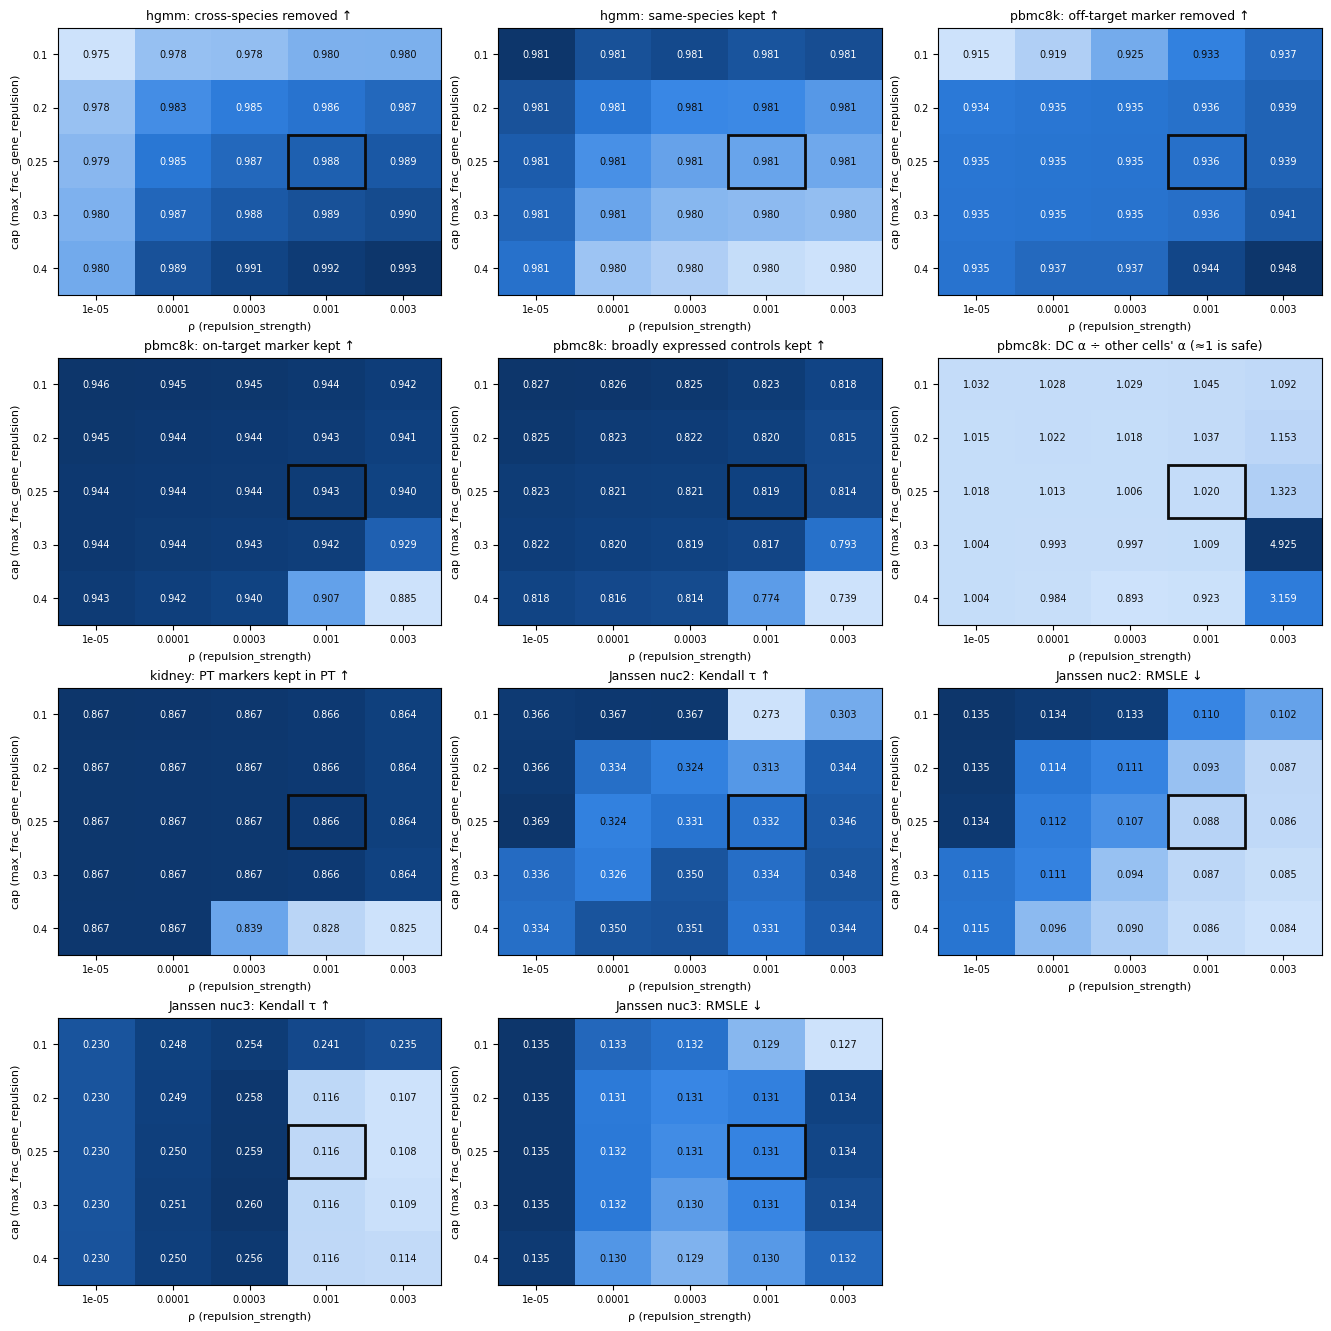

In [9]:
res = pd.read_csv(results_csv)
res = res[res["dataset"].isin(datasets)]
for c in ["rho", "kappa", "cap"]:
    res[c] = res[c].astype(float)

# Sequential blue ramp (light = low, dark = high); ordinal steps for rho in scatter plots
SEQ = ["#cde2fb", "#b7d3f6", "#9ec5f4", "#86b6ef", "#6da7ec", "#5598e7", "#3987e5",
       "#2a78d6", "#256abf", "#1c5cab", "#184f95", "#104281", "#0d366b"]
SEQ_CMAP = LinearSegmentedColormap.from_list("seq_blue", SEQ)

HEADLINE = [  # (dataset, column, title)
    ("hgmm_12k", "hgmm_noise_removed", "hgmm: cross-species removed ↑"),
    ("hgmm_12k", "hgmm_signal_kept", "hgmm: same-species kept ↑"),
    ("pbmc8k", "pbmc_offtarget_removed", "pbmc8k: off-target marker removed ↑"),
    ("pbmc8k", "pbmc_ontarget_kept", "pbmc8k: on-target marker kept ↑"),
    ("pbmc8k", "pbmc_controls_kept", "pbmc8k: broadly expressed controls kept ↑"),
    ("pbmc8k", "pbmc_DC_alpha_ratio", "pbmc8k: DC α ÷ other cells' α (≈1 is safe)"),
    ("kidney_nuclei_10k", "kidney_PT_markers_kept", "kidney: PT markers kept in PT ↑"),
    ("janssen_nuc2", "janssen_tau", "Janssen nuc2: Kendall τ ↑"),
    ("janssen_nuc2", "janssen_rmsle", "Janssen nuc2: RMSLE ↓"),
    ("janssen_nuc3", "janssen_tau", "Janssen nuc3: Kendall τ ↑"),
    ("janssen_nuc3", "janssen_rmsle", "Janssen nuc3: RMSLE ↓"),
]
HEADLINE = [h for h in HEADLINE if h[0] in set(res["dataset"]) and h[1] in res.columns]


def grid(ds, col, mode, rhos, caps):
    d = res[(res.dataset == ds) & (res["mode"] == mode) & np.isclose(res.kappa, default["kappa"])]
    g = d.pivot_table(index="cap", columns="rho", values=col)
    return g.reindex(index=caps, columns=rhos)


def heatmap(ax, g, title, fmt="{:.3f}"):
    vals = g.values.astype(float)
    finite = vals[np.isfinite(vals)]
    lo, hi = (finite.min(), finite.max()) if finite.size else (0, 1)
    ax.imshow(vals, cmap=SEQ_CMAP, vmin=lo, vmax=hi if hi > lo else lo + 1e-9, aspect="auto")
    for i in range(vals.shape[0]):
        for j in range(vals.shape[1]):
            if np.isfinite(vals[i, j]):
                shade = (vals[i, j] - lo) / (hi - lo) if hi > lo else 0
                ax.text(j, i, fmt.format(vals[i, j]), ha="center", va="center", fontsize=7,
                        color="white" if shade > 0.55 else "#0b0b0b")
    rhos, caps = list(g.columns), list(g.index)
    if default["rho"] in rhos and default["cap"] in caps:
        di, dj = caps.index(default["cap"]), rhos.index(default["rho"])
        ax.add_patch(Rectangle((dj - 0.5, di - 0.5), 1, 1, fill=False, edgecolor="#0b0b0b", lw=2))
    ax.set_xticks(range(len(rhos)), [f"{r:g}" for r in rhos], fontsize=7)
    ax.set_yticks(range(len(caps)), [f"{c:g}" for c in caps], fontsize=7)
    ax.set_xlabel("ρ (repulsion_strength)", fontsize=8)
    ax.set_ylabel("cap (max_frac_gene_repulsion)", fontsize=8)
    ax.set_title(title, fontsize=9)


def save(fig, name):
    for ext in ("png", "pdf"):
        fig.savefig(os.path.join(out_dir, f"{name}.{ext}"), dpi=300, bbox_inches="tight")


ncol = 3
nrow = int(np.ceil(len(HEADLINE) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.4 * ncol, 3.3 * nrow), constrained_layout=True, squeeze=False)
for ax, (ds, col, title) in zip(axes.flat, HEADLINE):
    heatmap(ax, grid(ds, col, "default", rho_grid, cap_grid), title)
for ax in axes.flat[len(HEADLINE):]:
    ax.axis("off")
save(fig, "heatmaps_default")
plt.show()

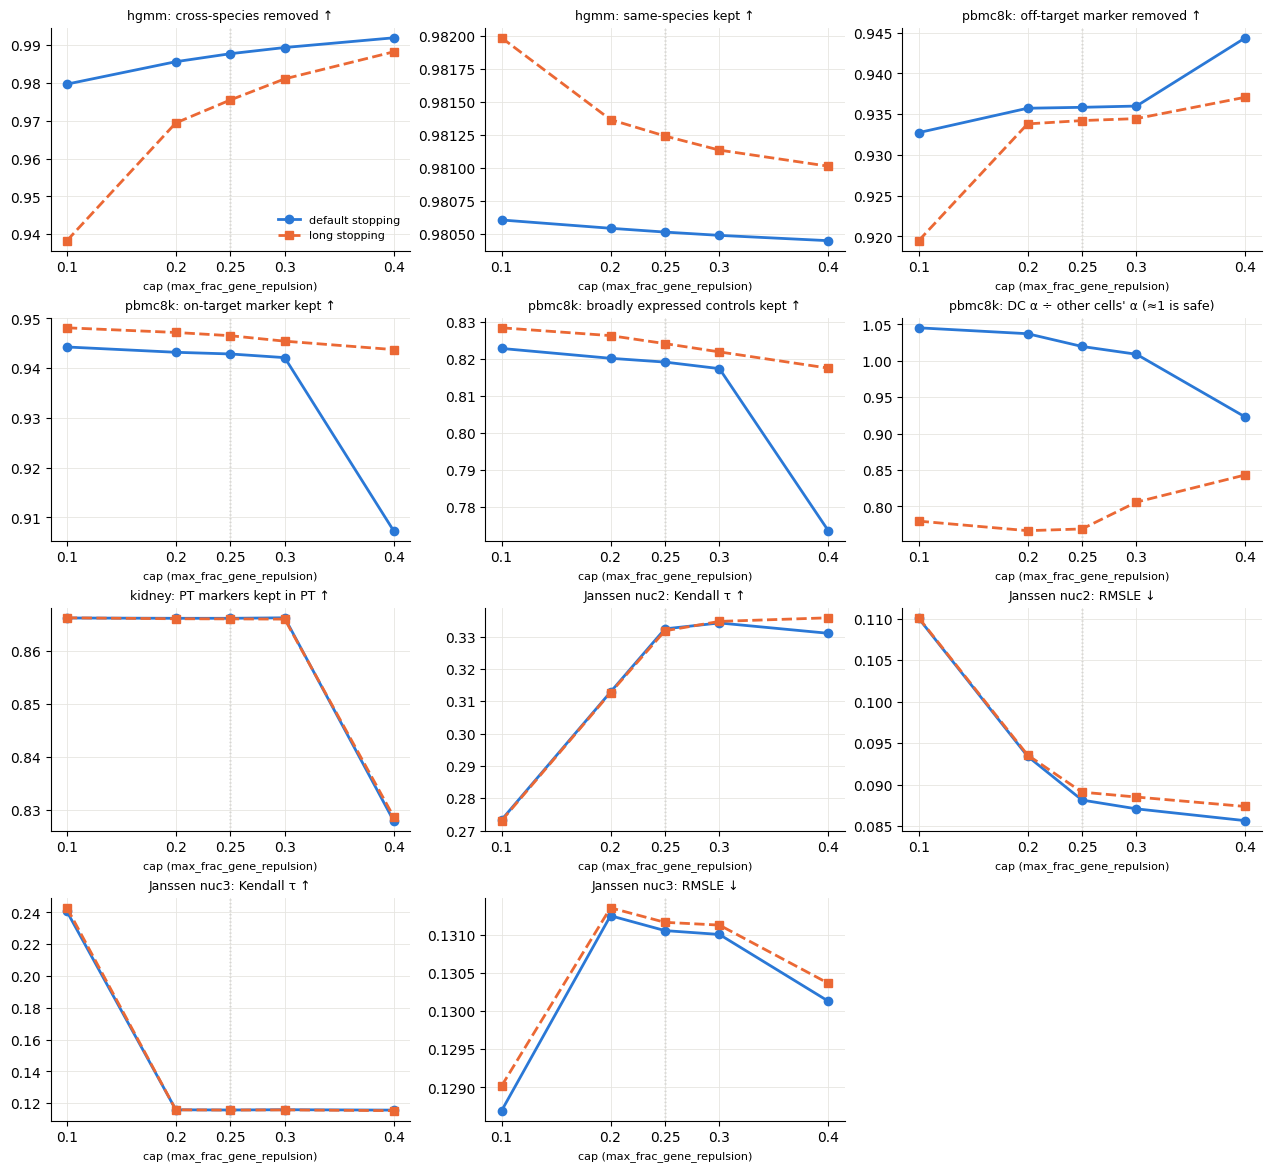

In [11]:
# convergence check: each metric along the cap column at the default rho, both stopping modes
fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 2.9 * nrow), constrained_layout=True, squeeze=False)
col_rows = res[np.isclose(res.rho, default["rho"]) & np.isclose(res.kappa, default["kappa"]) & res.cap.isin(long_cap)]
for ax, (ds, col, title) in zip(axes.flat, HEADLINE):
    for mode, color, style in [("default", "#2a78d6", "-o"), ("long", "#eb6834", "--s")]:
        d = col_rows[(col_rows.dataset == ds) & (col_rows["mode"] == mode)].sort_values("cap")
        ax.plot(d.cap, d[col], style, color=color, lw=2, markersize=6, label=f"{mode} stopping")
    ax.axvline(default["cap"], color="#8c8b86", lw=1, ls=":", zorder=0)
    ax.set_xticks(long_cap, [f"{c:g}" for c in long_cap])
    ax.set_xlabel("cap (max_frac_gene_repulsion)", fontsize=8)
    ax.set_title(title, fontsize=9)
    ax.grid(color="#e6e5e1", lw=0.6)
    ax.spines[["top", "right"]].set_visible(False)
for ax in axes.flat[len(HEADLINE):]:
    ax.axis("off")
axes.flat[0].legend(frameon=False, fontsize=8)
save(fig, "convergence_check")
plt.show()

### β prior strength

κ swept at the default ρ and cap, default stopping. κ = 0 is the maximum-likelihood β, and larger κ
holds β̂ closer to 0.01.

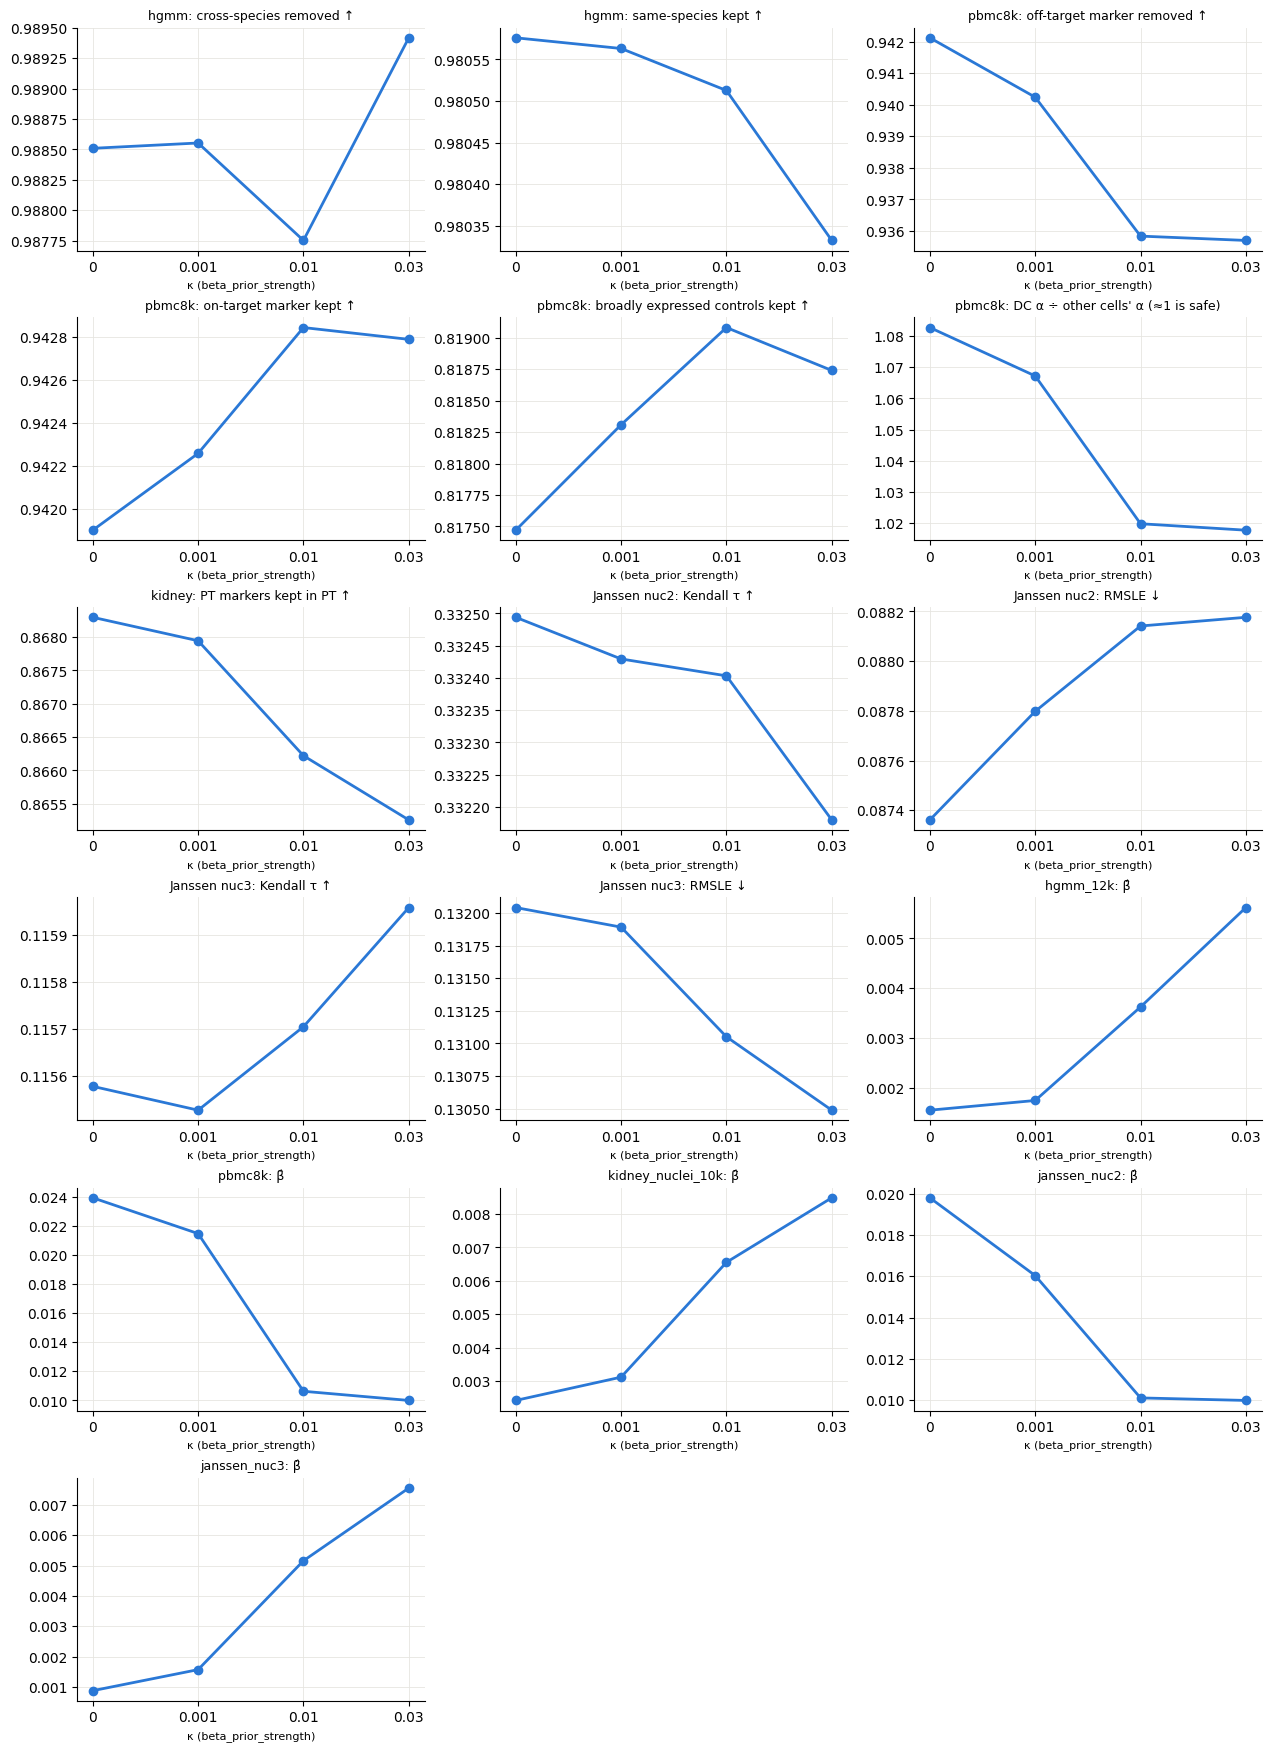

In [12]:
k_rows = res[np.isclose(res.rho, default["rho"]) & np.isclose(res.cap, default["cap"]) & res.kappa.isin(kappa_grid)]
panels = HEADLINE + [(ds, "beta_hat", f"{ds}: β̂") for ds in datasets if ds in set(res["dataset"])]
ncol = 3
fig, axes = plt.subplots(int(np.ceil(len(panels) / ncol)), ncol, figsize=(4.2 * ncol, 2.9 * np.ceil(len(panels) / ncol)),
                         constrained_layout=True, squeeze=False)
xpos = {k: i for i, k in enumerate(kappa_grid)}
for ax, (ds, col, title) in zip(axes.flat, panels):
    d = k_rows[(k_rows.dataset == ds) & (k_rows["mode"] == "default")].sort_values("kappa")
    ax.plot([xpos[k] for k in d.kappa], d[col], "-o", color="#2a78d6", lw=2, markersize=6)
    ax.set_xticks(range(len(kappa_grid)), [f"{k:g}" for k in kappa_grid])
    ax.set_xlabel("κ (beta_prior_strength)", fontsize=8)
    ax.set_title(title, fontsize=9)
    ax.grid(color="#e6e5e1", lw=0.6)
    ax.spines[["top", "right"]].set_visible(False)
for ax in axes.flat[len(panels):]:
    ax.axis("off")
save(fig, "kappa_sweep")
plt.show()

### Without the global component

The κ = 0 runs above remove only the prior; $\beta$ is still fitted. To remove the global component itself, these runs fix $\beta = 0$ (initial $\beta = 0$ and a prior with mode 0 and very large strength), at the default ρ and cap and the default stopping rule.

In [10]:
no_global_csv = os.path.join(out_dir, "no_global_results.csv")
no_global = dict(init_beta=0.0, beta_prior_mode=0.0)   # with kappa = 1e6 below, beta stays at 0
rows = [] if (overwrite or not os.path.exists(no_global_csv)) else pd.read_csv(no_global_csv).to_dict("records")
done_ds = {r["dataset"] for r in rows}
for ds in datasets:
    if ds in done_ds:
        continue
    adata = ad.read_h5ad(input_paths[ds])
    rows.append(dict(run="beta = 0", **run_setting(ds, adata, default["rho"], 1e6, default["cap"], "default", tag="_nobeta", **no_global)))
    pd.DataFrame(rows).to_csv(no_global_csv, index=False)
    del adata
ng = pd.DataFrame(rows)
ref = res[np.isclose(res.rho, default["rho"]) & np.isclose(res.kappa, default["kappa"]) & np.isclose(res.cap, default["cap"])
          & (res["mode"] == "default")].assign(run="default")
cmp = pd.concat([ref, ng], ignore_index=True)
cols = ["run", "beta_hat"] + [c for ds, c, _ in HEADLINE]
with pd.option_context("display.max_columns", 50, "display.width", 250):
    for ds in datasets:
        d = cmp[cmp.dataset == ds].dropna(axis=1, how="all")
        print(f"=== {ds} ===")
        display(d[[c for c in dict.fromkeys(cols) if c in d.columns]].round(4))

=== hgmm_12k ===


,run,beta_hat,hgmm_noise_removed,hgmm_signal_kept
0,default,0.0036,0.9878,0.9805
5,beta = 0,0.0000,0.9879,0.9806


=== pbmc8k ===


,run,beta_hat,pbmc_offtarget_removed,pbmc_ontarget_kept,pbmc_controls_kept,pbmc_DC_alpha_ratio
1,default,0.0106,0.9358,0.9428,0.8191,1.0197
6,beta = 0,0.0000,0.9329,0.9434,0.8195,0.9907


=== kidney_nuclei_10k ===


,run,beta_hat,kidney_PT_markers_kept
2,default,0.0066,0.8662
7,beta = 0,0.0000,0.8695


=== janssen_nuc2 ===


,run,beta_hat,janssen_tau,janssen_rmsle
3,default,0.0101,0.3324,0.0881
8,beta = 0,0.0000,0.3319,0.0893


=== janssen_nuc3 ===


,run,beta_hat,janssen_tau,janssen_rmsle
4,default,0.0052,0.1157,0.1311
9,beta = 0,0.0000,0.1154,0.1323


### Summary table

Every setting and metric, with the default setting first. The table is descriptive: use it with
the plots above to judge how much each dataset's results move across the grid.

In [13]:
metric_cols = [c for c in res.columns if c not in ("dataset", "rho", "kappa", "cap", "mode", "seconds")
               and not c.startswith("kidney_removed_")]
summary = res.copy()
summary["is_default"] = (np.isclose(summary.rho, default["rho"]) & np.isclose(summary.kappa, default["kappa"])
                         & np.isclose(summary.cap, default["cap"]))
summary = summary.sort_values(["dataset", "mode", "is_default", "rho", "cap", "kappa"],
                              ascending=[True, True, False, True, True, True])
summary.to_csv(os.path.join(out_dir, "summary.csv"), index=False)
with pd.option_context("display.max_rows", 500, "display.max_columns", 50, "display.width", 250):
    for ds in datasets:
        d = summary[summary.dataset == ds].dropna(axis=1, how="all")
        cols = ["rho", "kappa", "cap", "mode", "is_default"] + [c for c in metric_cols if c in d.columns]
        print(f"=== {ds} ===")
        display(d[cols].round(4))

=== hgmm_12k ===


,rho,kappa,cap,mode,is_default,beta_hat,median_alpha,removed,iterations,hgmm_noise_removed,hgmm_signal_kept
17,0.0010,0.010,0.25,default,True,0.0036,0.0335,0.1066,31,0.9878,0.9805
0,0.0000,0.010,0.10,default,False,0.0033,0.0333,0.1062,29,0.9747,0.9806
1,0.0000,0.010,0.20,default,False,0.0033,0.0334,0.1063,29,0.9780,0.9806
2,0.0000,0.010,0.25,default,False,0.0033,0.0334,0.1063,29,0.9790,0.9806
3,0.0000,0.010,0.30,default,False,0.0034,0.0335,0.1064,29,0.9797,0.9806
4,0.0000,0.010,0.40,default,False,0.0034,0.0335,0.1064,29,0.9804,0.9806
5,0.0001,0.010,0.10,default,False,0.0033,0.0334,0.1063,29,0.9781,0.9806
6,0.0001,0.010,0.20,default,False,0.0035,0.0335,0.1064,30,0.9831,0.9806
7,0.0001,0.010,0.25,default,False,0.0035,0.0335,0.1065,30,0.9853,0.9805
8,0.0001,0.010,0.30,default,False,0.0035,0.0336,0.1066,30,0.9870,0.9805


=== pbmc8k ===


,rho,kappa,cap,mode,is_default,beta_hat,median_alpha,removed,iterations,pbmc_offtarget_removed,pbmc_ontarget_kept,pbmc_controls_kept,pbmc_DC_median_alpha,pbmc_DC_alpha_ratio
50,0.0010,0.010,0.25,default,True,0.0106,0.0699,0.1488,384,0.9358,0.9428,0.8191,0.0713,1.0197
33,0.0000,0.010,0.10,default,False,0.0099,0.0631,0.1422,312,0.9151,0.9457,0.8266,0.0651,1.0320
34,0.0000,0.010,0.20,default,False,0.0100,0.0647,0.1437,317,0.9341,0.9452,0.8249,0.0657,1.0151
35,0.0000,0.010,0.25,default,False,0.0102,0.0667,0.1456,307,0.9347,0.9445,0.8227,0.0679,1.0184
36,0.0000,0.010,0.30,default,False,0.0105,0.0677,0.1466,315,0.9348,0.9443,0.8217,0.0680,1.0039
37,0.0000,0.010,0.40,default,False,0.0104,0.0711,0.1497,334,0.9352,0.9432,0.8180,0.0714,1.0039
38,0.0001,0.010,0.10,default,False,0.0100,0.0638,0.1428,319,0.9186,0.9454,0.8259,0.0655,1.0283
39,0.0001,0.010,0.20,default,False,0.0102,0.0667,0.1455,322,0.9348,0.9443,0.8229,0.0681,1.0220
40,0.0001,0.010,0.25,default,False,0.0105,0.0680,0.1468,334,0.9350,0.9438,0.8214,0.0689,1.0134
41,0.0001,0.010,0.30,default,False,0.0104,0.0694,0.1481,360,0.9351,0.9435,0.8200,0.0689,0.9926


=== kidney_nuclei_10k ===


,rho,kappa,cap,mode,is_default,beta_hat,median_alpha,removed,iterations,kidney_PT_markers_kept,kidney_PT_markers_removed_elsewhere
83,0.0010,0.010,0.25,default,True,0.0066,0.1037,0.1785,270,0.8662,0.2629
66,0.0000,0.010,0.10,default,False,0.0066,0.1005,0.1762,238,0.8675,0.2540
67,0.0000,0.010,0.20,default,False,0.0066,0.1010,0.1767,243,0.8671,0.2544
68,0.0000,0.010,0.25,default,False,0.0067,0.1005,0.1766,280,0.8670,0.2524
69,0.0000,0.010,0.30,default,False,0.0067,0.1014,0.1771,245,0.8670,0.2578
70,0.0000,0.010,0.40,default,False,0.0067,0.1018,0.1774,253,0.8670,0.2601
71,0.0001,0.010,0.10,default,False,0.0066,0.1008,0.1765,242,0.8673,0.2545
72,0.0001,0.010,0.20,default,False,0.0067,0.1007,0.1767,295,0.8670,0.2522
73,0.0001,0.010,0.25,default,False,0.0067,0.1016,0.1772,252,0.8669,0.2581
74,0.0001,0.010,0.30,default,False,0.0067,0.1019,0.1774,263,0.8669,0.2598


=== janssen_nuc2 ===


,rho,kappa,cap,mode,is_default,beta_hat,median_alpha,removed,iterations,janssen_n,janssen_tau,janssen_rmsle,janssen_median_estimate,janssen_median_truth,janssen_pt_median_estimate,janssen_pt_median_truth,janssen_pt_noise_removed,janssen_pt_signal_kept,janssen_constitutive_kept
116,0.0010,0.010,0.25,default,True,0.0101,0.3646,0.3567,477,1514.0,0.3324,0.0881,0.3303,0.3312,0.3303,0.3155,0.7708,0.6112,0.6732
99,0.0000,0.010,0.10,default,False,0.0081,0.2196,0.2183,697,1514.0,0.3656,0.1353,0.2123,0.3312,0.1997,0.3155,0.5983,0.7676,0.7865
100,0.0000,0.010,0.20,default,False,0.0084,0.2639,0.2524,818,1514.0,0.3661,0.1349,0.2129,0.3312,0.2005,0.3155,0.5988,0.7186,0.7591
101,0.0000,0.010,0.25,default,False,0.0085,0.2731,0.2609,1091,1514.0,0.3686,0.1339,0.2142,0.3312,0.2003,0.3155,0.6298,0.7072,0.7523
102,0.0000,0.010,0.30,default,False,0.0090,0.3018,0.2926,399,1514.0,0.3355,0.1153,0.2565,0.3312,0.2540,0.3155,0.6543,0.6782,0.7276
103,0.0000,0.010,0.40,default,False,0.0090,0.3027,0.2935,447,1514.0,0.3336,0.1147,0.2589,0.3312,0.2568,0.3155,0.6585,0.6776,0.7269
104,0.0001,0.010,0.10,default,False,0.0084,0.2404,0.2413,803,1514.0,0.3667,0.1337,0.2154,0.3312,0.2047,0.3155,0.6017,0.7475,0.7755
105,0.0001,0.010,0.20,default,False,0.0091,0.3178,0.3090,501,1514.0,0.3337,0.1139,0.2626,0.3312,0.2597,0.3155,0.6695,0.6619,0.7169
106,0.0001,0.010,0.25,default,False,0.0091,0.3209,0.3115,751,1514.0,0.3241,0.1121,0.2747,0.3312,0.2726,0.3155,0.6842,0.6601,0.7151
107,0.0001,0.010,0.30,default,False,0.0092,0.3221,0.3142,704,1514.0,0.3258,0.1108,0.2762,0.3312,0.2733,0.3155,0.6875,0.6553,0.7118


=== janssen_nuc3 ===


,rho,kappa,cap,mode,is_default,beta_hat,median_alpha,removed,iterations,janssen_n,janssen_tau,janssen_rmsle,janssen_median_estimate,janssen_median_truth,janssen_pt_median_estimate,janssen_pt_median_truth,janssen_pt_noise_removed,janssen_pt_signal_kept,janssen_constitutive_kept
149,0.0010,0.010,0.25,default,True,0.0052,0.1429,0.1842,344,398.0,0.1157,0.1311,0.1181,0.1795,0.1126,0.1697,0.7320,0.8614,0.8721
132,0.0000,0.010,0.10,default,False,0.0051,0.1262,0.1637,363,398.0,0.2297,0.1353,0.0778,0.1795,0.0779,0.1697,0.5185,0.8767,0.8897
133,0.0000,0.010,0.20,default,False,0.0051,0.1267,0.1642,368,398.0,0.2298,0.1353,0.0778,0.1795,0.0779,0.1697,0.5186,0.8763,0.8895
134,0.0000,0.010,0.25,default,False,0.0051,0.1267,0.1642,372,398.0,0.2298,0.1353,0.0778,0.1795,0.0779,0.1697,0.5185,0.8763,0.8895
135,0.0000,0.010,0.30,default,False,0.0051,0.1266,0.1641,377,398.0,0.2297,0.1353,0.0778,0.1795,0.0778,0.1697,0.5185,0.8764,0.8895
136,0.0000,0.010,0.40,default,False,0.0052,0.1269,0.1645,392,398.0,0.2303,0.1350,0.0781,0.1795,0.0778,0.1697,0.5324,0.8764,0.8892
137,0.0001,0.010,0.10,default,False,0.0052,0.1309,0.1679,324,398.0,0.2483,0.1325,0.0807,0.1795,0.0791,0.1697,0.5952,0.8747,0.8872
138,0.0001,0.010,0.20,default,False,0.0052,0.1326,0.1696,355,398.0,0.2488,0.1315,0.0835,0.1795,0.0816,0.1697,0.5965,0.8734,0.8864
139,0.0001,0.010,0.25,default,False,0.0053,0.1328,0.1699,381,398.0,0.2496,0.1315,0.0835,0.1795,0.0816,0.1697,0.6103,0.8735,0.8863
140,0.0001,0.010,0.30,default,False,0.0053,0.1327,0.1699,420,398.0,0.2508,0.1316,0.0835,0.1795,0.0816,0.1697,0.6133,0.8736,0.8864


## Initial ambient fraction (hgmm_12k)

Every cell starts EM with α_i = `init_alpha` (default 0.9). Because the likelihood is nearly flat along
directions that trade cell-type expression for contamination, the starting point helps choose among solutions
of almost equal likelihood. A high starting α_i lets the ambient component explain ambient-shaped counts from the
first iteration, so the cell-type profiles p_k start from, and stay near, the cell's own expression; a low
starting α_i asks p_k to explain those counts first.

The human–mouse mixture gives a direct readout of profile purity: a clean human profile puts almost no mass on
mouse genes, and a clean mouse profile almost none on human genes, so any cross-species mass in p_k is ambient
RNA absorbed into the profile. For each `init_alpha` this section records

* the cross-species mass of each final profile p_k, compared with the starting profiles (mean raw counts of each
  label, which include the doublets that are later scored out) and with the cross-species share of the ambient
  profile,
* the cross-species counts removed and same-species counts kept, as in the main sweep, and β̂ and median α̂.

`init_alpha` should not exceed `alpha_cap` (0.9), the burn-in cap on α_i. The runs use the hgmm input prepared
above and are cached in `init_alpha_results.csv`; set `overwrite = True` above to rerun them.

In [10]:
init_alpha_grid = [0.1, 0.3, 0.5, 0.7, 0.9]
init_alpha_modes = ["default"]   # add "long" to also run each setting to convergence
init_alpha_csv = os.path.join(out_dir, "init_alpha_results.csv")
hgmm_input = prepare_10x("hgmm_12k")   # reuses the prepared input if it exists

hgmm_12k: reused /home/mcaskey/cellsweep/notebooks/data/parameter_sweep/hgmm_12k_input.h5ad


In [11]:
def profile_cross_species(out):
    """Cross-species mass of each cell-type profile: final (p_hat), at the start (raw-count profile), and in the ambient profile."""
    is_h = (out.var["genome"] == "hg19").values
    names = list(np.asarray(out.uns["celltype_names"]).astype(str))
    p = np.asarray(out.uns["p_hat"], dtype=float)
    p0 = np.asarray(out.uns["celltype_profile"], dtype=float)
    p0 = p0 / p0.sum(axis=1, keepdims=True)
    h, m = names.index("hg19"), names.index("mm10")
    return dict(p_human_on_mouse=p[h, ~is_h].sum(), p_mouse_on_human=p[m, is_h].sum(),
                start_human_on_mouse=p0[h, ~is_h].sum(), start_mouse_on_human=p0[m, is_h].sum(),
                ambient_mouse_share=float(out.var["ambient_hat"].values[~is_h].sum()))


def run_init_alpha(adata, init_alpha, mode):
    log_path = os.path.join(log_dir, f"hgmm_12k_init_alpha{init_alpha:g}_{mode}.log")
    t = time.time()
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        out = denoise(adata.copy(), keep_empties=True, init_alpha=init_alpha, repulsion_strength=default["rho"],
                                   beta_prior_strength=default["kappa"], max_frac_gene_repulsion=default["cap"],
                                   freeze_ambient_profile=True, empty_droplet_method="threshold",
                                   umi_cutoff=int(adata.uns["umi_cutoff"]), threads=threads, verbose=1,
                                   log_file=log_path, **modes[mode])
    return dict(dataset="hgmm_12k", init_alpha=init_alpha, mode=mode, **score_common(out, log_path, time.time() - t),
                **score_hgmm(out), **profile_cross_species(out))


ia_done = set()
if os.path.exists(init_alpha_csv) and not overwrite:
    ia_done = {(f"{a:g}", m) for a, m in pd.read_csv(init_alpha_csv)[["init_alpha", "mode"]].itertuples(index=False)}
elif os.path.exists(init_alpha_csv):
    os.remove(init_alpha_csv)
ia_todo = [(a, m) for m in init_alpha_modes for a in init_alpha_grid if (f"{a:g}", m) not in ia_done]
print(f"hgmm_12k init_alpha: {len(ia_todo)} runs to do")
if ia_todo:
    adata = ad.read_h5ad(hgmm_input)
    for init_alpha, mode in ia_todo:
        row = run_init_alpha(adata, init_alpha, mode)
        prev = pd.read_csv(init_alpha_csv) if os.path.exists(init_alpha_csv) else pd.DataFrame()
        pd.concat([prev, pd.DataFrame([row])], ignore_index=True).to_csv(init_alpha_csv, index=False)
        print(f"  init_alpha={init_alpha:g} {mode:7s} -> cross-species removed={row['hgmm_noise_removed']:.4f} "
              f"p_human_on_mouse={row['p_human_on_mouse']:.2e} p_mouse_on_human={row['p_mouse_on_human']:.2e} "
              f"iters={row['iterations']} ({row['seconds']:.0f}s)")
    del adata

hgmm_12k init_alpha: 0 runs to do


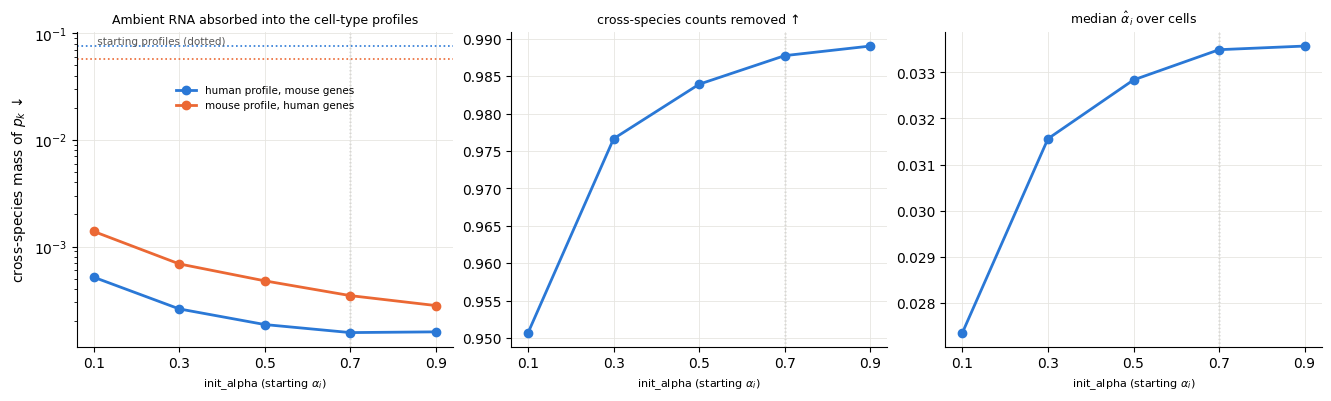

,init_alpha,mode,p_human_on_mouse,p_mouse_on_human,hgmm_noise_removed,hgmm_signal_kept,beta_hat,median_alpha,removed,iterations,seconds
0,0.1,default,0.00052,0.00139,0.95075,0.98132,0.00835,0.02736,0.10519,34,17.9
1,0.3,default,0.00026,0.00069,0.97666,0.98074,0.00515,0.03156,0.10613,32,8.2
2,0.5,default,0.00019,0.00048,0.98393,0.98059,0.00415,0.03284,0.10640,31,8.1
3,0.7,default,0.00016,0.00035,0.98775,0.98051,0.00362,0.03349,0.10658,31,8.1
4,0.9,default,0.00016,0.00028,0.98903,0.98050,0.00358,0.03357,0.10673,35,8.8


starting profiles: human on mouse genes 0.0760, mouse on human genes 0.0574; ambient profile mouse share 0.349


In [12]:
ia = pd.read_csv(init_alpha_csv)
ia = ia[ia.init_alpha.isin(init_alpha_grid) & ia["mode"].isin(init_alpha_modes)].sort_values(["mode", "init_alpha"])
HUMAN, MOUSE = "#2a78d6", "#eb6834"
STYLE = {"default": ("-o", "default stopping"), "long": ("--s", "long stopping")}

fig, axes = plt.subplots(1, 3, figsize=(13.2, 3.9), constrained_layout=True)
ax = axes[0]
for mode, d in ia.groupby("mode"):
    style, label = STYLE[mode]
    suffix = f" ({label})" if len(init_alpha_modes) > 1 else ""
    ax.plot(d.init_alpha, d.p_human_on_mouse, style, color=HUMAN, lw=2, ms=6, label=f"human profile, mouse genes{suffix}")
    ax.plot(d.init_alpha, d.p_mouse_on_human, style, color=MOUSE, lw=2, ms=6, label=f"mouse profile, human genes{suffix}")
start = ia.iloc[0]
ax.axhline(start.start_human_on_mouse, color=HUMAN, ls=":", lw=1.2)
ax.axhline(start.start_mouse_on_human, color=MOUSE, ls=":", lw=1.2)
ax.text(init_alpha_grid[0], start.start_human_on_mouse, " starting profiles (dotted)", va="bottom", fontsize=7.5, color="0.35")
ax.set_yscale("log")
ax.set_ylabel("cross-species mass of $p_k$ ↓")
ax.set_title("Ambient RNA absorbed into the cell-type profiles", fontsize=9)
# in the empty band between the final profiles (bottom) and the starting profiles (top)
ax.legend(frameon=False, fontsize=7.5, loc="upper center", bbox_to_anchor=(0.5, 0.86))

for ax, col, title in [(axes[1], "hgmm_noise_removed", "cross-species counts removed ↑"),
                       (axes[2], "median_alpha", "median $\\hat{\\alpha}_i$ over cells")]:
    for mode, d in ia.groupby("mode"):
        style, label = STYLE[mode]
        ax.plot(d.init_alpha, d[col], style, color="#2a78d6", lw=2, ms=6, label=label)
    ax.set_title(title, fontsize=9)
    if len(init_alpha_modes) > 1:
        ax.legend(frameon=False, fontsize=7)
for ax in axes:
    ax.set_xticks(init_alpha_grid, [f"{a:g}" for a in init_alpha_grid])
    ax.set_xlabel("init_alpha (starting $\\alpha_i$)", fontsize=8)
    ax.axvline(0.7, color="#8c8b86", lw=1, ls=":", zorder=0)   # default init_alpha
    ax.grid(color="#e6e5e1", lw=0.6)
    ax.spines[["top", "right"]].set_visible(False)
save(fig, "init_alpha_sweep")
plt.show()

with pd.option_context("display.width", 250, "display.max_columns", 30):
    display(ia[["init_alpha", "mode", "p_human_on_mouse", "p_mouse_on_human", "hgmm_noise_removed", "hgmm_signal_kept",
                "beta_hat", "median_alpha", "removed", "iterations", "seconds"]].round(5))
print(f"starting profiles: human on mouse genes {start.start_human_on_mouse:.4f}, mouse on human genes "
      f"{start.start_mouse_on_human:.4f}; ambient profile mouse share {start.ambient_mouse_share:.3f}")

## Initial ambient fraction × repulsion, including the Janssen scRNA-seq replicates

On the Janssen et al. scRNA-seq replicates, the default settings removed far more from proximal tubule (PT) cells than
the genotype estimates: a median of 27% vs 10% (rep2) and 31% vs 2.5% (rep3). In a test on rep2 and rep3, lowering
`init_alpha` to 0.5 or turning repulsion off each brought this down (rep3: 12%), while with repulsion off `init_alpha`
had no effect. This section measures the same settings on every dataset, so that a change for the scRNA-seq replicates can be
checked against the benchmarks the defaults were chosen on:

* `init_alpha` ∈ {0.9, 0.7, 0.5} × ρ ∈ {0, 1e-4, 3e-4, 1e-3} × cap ∈ {0.2, 0.25, 0.3}, default stopping;
* run to convergence at cap 0.25 for ρ ∈ {0, 1e-3} at each `init_alpha`.

The Janssen scRNA-seq replicates (rep1–3) use the authors' cell-type labels; nuc2 and nuc3 use the split PT labels of
the sections above. Results go to `init_repulsion_results.csv`; sections 1–4 are unchanged.

In [17]:
ir_datasets = datasets + ["janssen_rep1", "janssen_rep2", "janssen_rep3"]
ir_author_label_reps = ["rep1", "rep2", "rep3"]   # Janssen replicates scored with the authors' labels (no PT split)
ir_init_grid = [0.9, 0.7, 0.5]
ir_rho_grid = [0.0, 1e-4, 3e-4, 1e-3]
ir_cap_grid = [0.2, 0.25, 0.3]
ir_long = [(rho, default["cap"]) for rho in (0.0, default["rho"])]
ir_csv = os.path.join(out_dir, "init_repulsion_results.csv")

for ds in ir_datasets:
    if ds not in input_paths:
        rep = ds.split("_")[1]
        input_paths[ds] = prepare_janssen(rep) if rep in ir_author_label_reps else janssen_sweep_input(rep)
    SCORERS.setdefault(ds, score_janssen)

ir_runs = [(ia, r, c, "default") for ia in ir_init_grid for r in ir_rho_grid for c in ir_cap_grid]
ir_runs += [(ia, r, c, "long") for ia in ir_init_grid for r, c in ir_long]
print(f"{len(ir_runs)} runs per dataset x {len(ir_datasets)} datasets")

janssen_rep1: reused /home/mcaskey/cellsweep/notebooks/data/janssen2023/rep1/adata_raw_empty100.h5ad
janssen_rep2: reused /home/mcaskey/cellsweep/notebooks/data/janssen2023/rep2/adata_raw_empty100.h5ad
janssen_rep3: reused /home/mcaskey/cellsweep/notebooks/data/janssen2023/rep3/adata_raw_empty100.h5ad
42 runs per dataset x 8 datasets


In [18]:
ir_key = lambda ds, ia, r, c, m: (ds, f"{ia:g}", f"{r:g}", f"{c:g}", m)
ir_done = set()
if os.path.exists(ir_csv) and not overwrite:
    prev = pd.read_csv(ir_csv)
    ir_done = {ir_key(*x) for x in prev[["dataset", "init_alpha", "rho", "cap", "mode"]].itertuples(index=False)}
elif os.path.exists(ir_csv):
    os.remove(ir_csv)

for ds in ir_datasets:
    todo = [x for x in ir_runs if ir_key(ds, *x) not in ir_done]
    print(f"{ds}: {len(todo)} runs to do")
    if not todo:
        continue
    adata = ad.read_h5ad(input_paths[ds])
    for ia, rho, cap, mode in todo:
        row = dict(init_alpha=ia, **run_setting(ds, adata, rho, default["kappa"], cap, mode, init_alpha=ia))
        prev = pd.read_csv(ir_csv) if os.path.exists(ir_csv) else pd.DataFrame()
        pd.concat([prev, pd.DataFrame([row])], ignore_index=True).to_csv(ir_csv, index=False)
        print(f"  init_alpha={ia:g} rho={rho:g} cap={cap:g} {mode:7s} -> removed={row['removed']:.4f} "
              f"iters={row['iterations']} ({row['seconds']:.0f}s)")
    del adata

hgmm_12k: 0 runs to do
pbmc8k: 0 runs to do
kidney_nuclei_10k: 0 runs to do
janssen_nuc2: 0 runs to do
janssen_nuc3: 0 runs to do
janssen_rep1: 0 runs to do
janssen_rep2: 0 runs to do
janssen_rep3: 0 runs to do


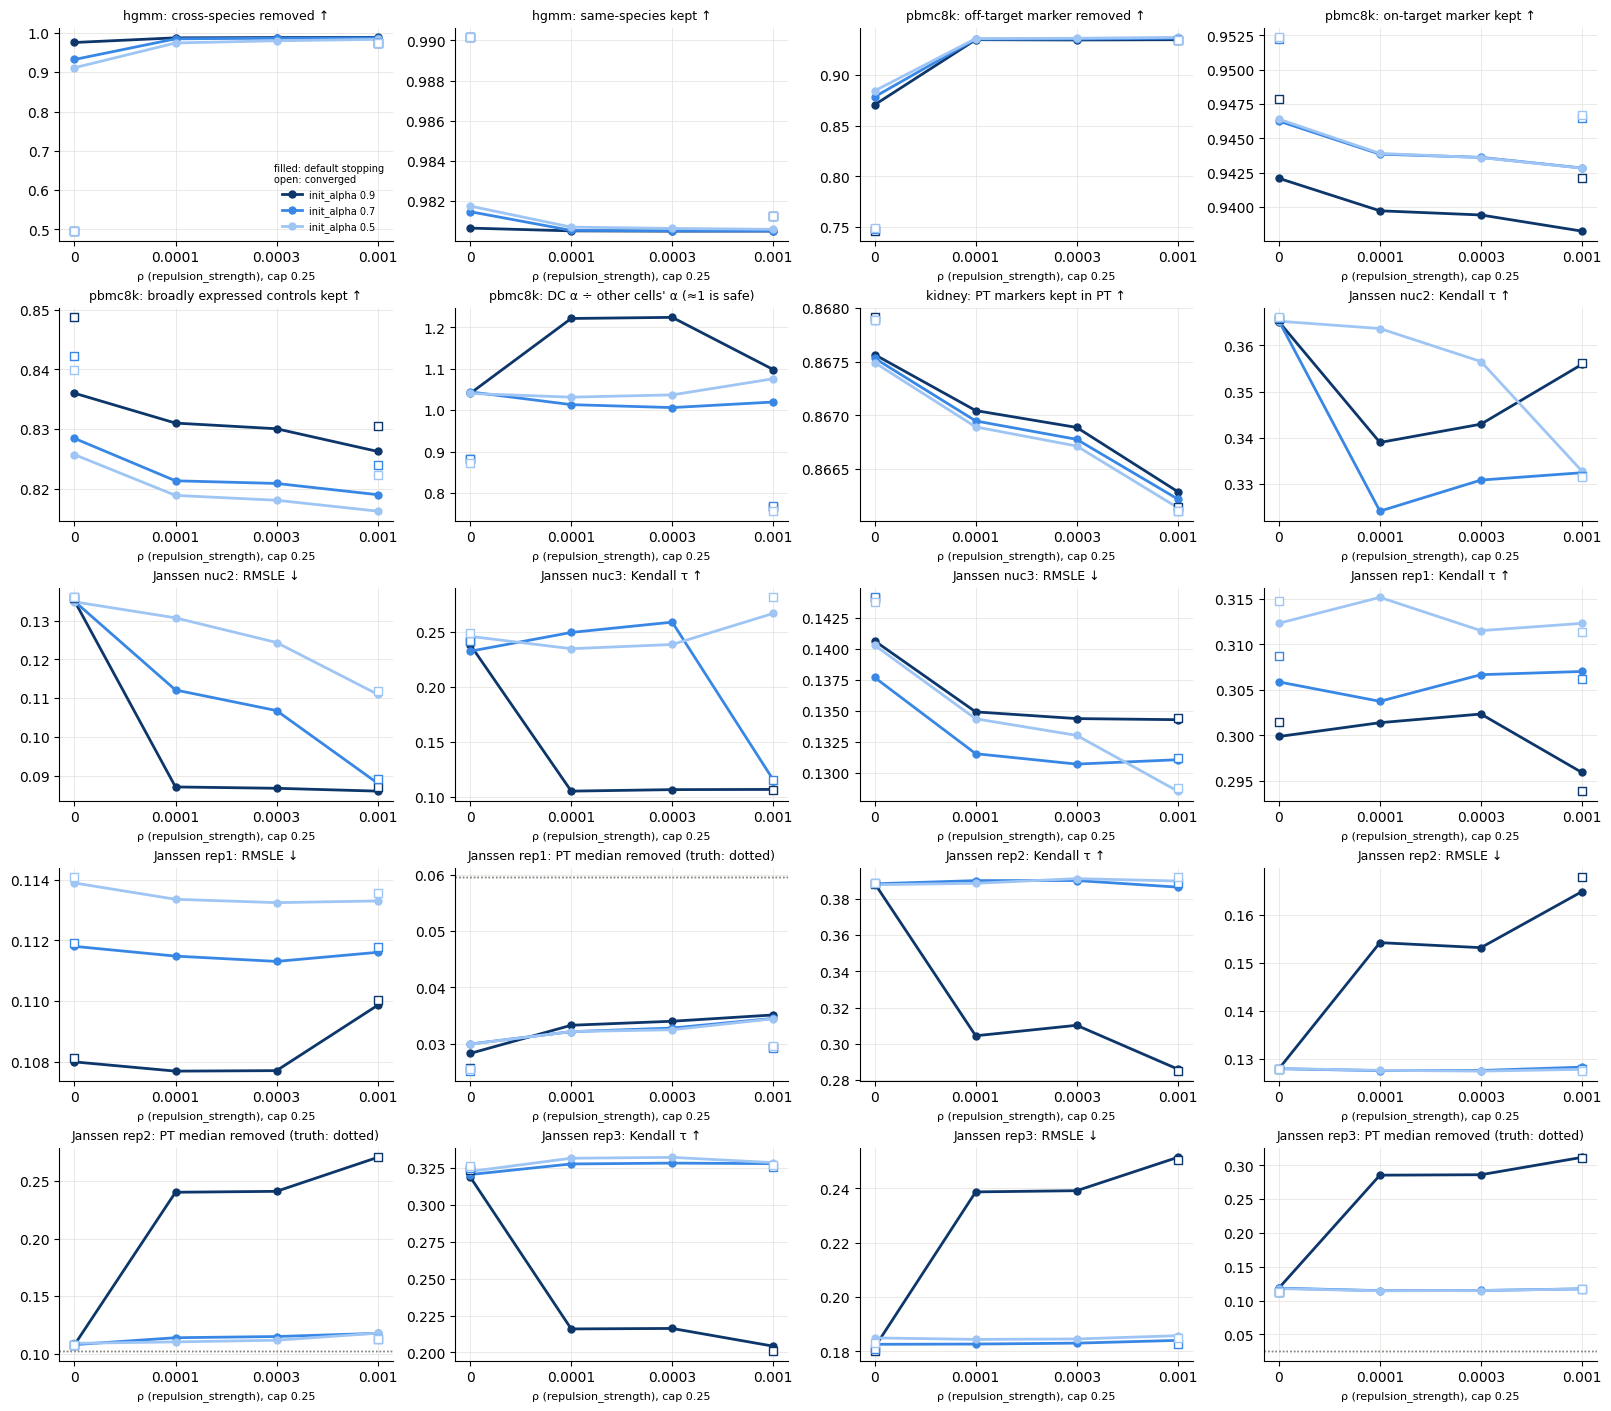

,dataset,init_alpha,rho,cap,mode,hgmm_noise_removed,hgmm_signal_kept,pbmc_offtarget_removed,pbmc_ontarget_kept,pbmc_controls_kept,pbmc_DC_alpha_ratio,kidney_PT_markers_kept,janssen_tau,janssen_rmsle,janssen_pt_median_estimate
25,hgmm_12k,0.5,0.0000,0.25,default,0.9117,0.9817,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28,hgmm_12k,0.5,0.0001,0.25,default,0.9748,0.9807,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31,hgmm_12k,0.5,0.0003,0.25,default,0.9804,0.9806,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34,hgmm_12k,0.5,0.0010,0.25,default,0.9839,0.9806,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,hgmm_12k,0.7,0.0000,0.25,default,0.9327,0.9815,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,hgmm_12k,0.7,0.0001,0.25,default,0.9853,0.9805,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19,hgmm_12k,0.7,0.0003,0.25,default,0.9869,0.9805,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22,hgmm_12k,0.7,0.0010,0.25,default,0.9878,0.9805,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,hgmm_12k,0.9,0.0000,0.25,default,0.9760,0.9806,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,hgmm_12k,0.9,0.0001,0.25,default,0.9878,0.9805,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
ir = pd.read_csv(ir_csv)
IR_PANELS = [h for h in HEADLINE if h[0] in set(ir.dataset)] + [
    (f"janssen_{r}", col, f"Janssen {r}: {name}") for r in ["rep1", "rep2", "rep3"]
    for col, name in [("janssen_tau", "Kendall τ ↑"), ("janssen_rmsle", "RMSLE ↓"),
                      ("janssen_pt_median_estimate", "PT median removed (truth: dotted)")]]
IR_PANELS = [h for h in IR_PANELS if h[0] in set(ir.dataset) and h[1] in ir.columns]
ia_color = {0.9: "#0d366b", 0.7: "#3987e5", 0.5: "#9ec5f4"}

ncol_ir = 4
nrow_ir = int(np.ceil(len(IR_PANELS) / ncol_ir))
fig, axes = plt.subplots(nrow_ir, ncol_ir, figsize=(4.0 * ncol_ir, 2.8 * nrow_ir), constrained_layout=True, squeeze=False)
xpos = {r: i for i, r in enumerate(ir_rho_grid)}
for ax, (ds, col, title) in zip(axes.flat, IR_PANELS):
    for ia in ir_init_grid:
        d = ir[(ir.dataset == ds) & np.isclose(ir.init_alpha, ia) & np.isclose(ir.cap, default["cap"])]
        dd = d[d["mode"] == "default"].sort_values("rho")
        ax.plot([xpos[r] for r in dd.rho], dd[col], "-o", color=ia_color[ia], lw=2, ms=5, label=f"init_alpha {ia:g}")
        dl = d[d["mode"] == "long"]
        ax.scatter([xpos[r] for r in dl.rho], dl[col], marker="s", facecolor="white", edgecolor=ia_color[ia], s=40, zorder=3)
        if col == "janssen_pt_median_estimate" and len(d):
            ax.axhline(d["janssen_pt_median_truth"].iloc[0], color="#8c8b86", ls=":", lw=1)
    ax.set_xticks(range(len(ir_rho_grid)), [f"{r:g}" for r in ir_rho_grid])
    ax.set_xlabel("ρ (repulsion_strength), cap 0.25", fontsize=8)
    ax.set_title(title, fontsize=9)
    ax.grid(color="#e6e5e1", lw=0.6)
    ax.spines[["top", "right"]].set_visible(False)
for ax in axes.flat[len(IR_PANELS):]:
    ax.axis("off")
axes.flat[0].legend(frameon=False, fontsize=7, title="filled: default stopping\nopen: converged", title_fontsize=7)
save(fig, "init_repulsion_sweep")
plt.show()

cols = ["dataset", "init_alpha", "rho", "cap", "mode"] + [c for _, c, _ in IR_PANELS if c in ir.columns]
with pd.option_context("display.max_rows", 500, "display.max_columns", 50, "display.width", 250):
    display(ir[np.isclose(ir.cap, default["cap"])][list(dict.fromkeys(cols))]
            .sort_values(["dataset", "mode", "init_alpha", "rho"]).round(4))